# Tutorial — RNA-Seq QC & Differential Expression with DESeq2
**Author:** Himanshu Goel | [Website](https://hgoelgithub.github.io)  
**Dataset:** Open TG-GATEs — Acetaminophen (APAP), rat liver, in vivo

---

## What this tutorial covers

RNA-Seq quantifies genome-wide gene expression by counting reads mapping to each gene. The standard analysis pipeline is:

```
Raw counts → QC & filtering → Normalization → DE testing → Visualization
```

We use **pydeseq2** — the official Python port of the R DESeq2 package — which implements:
- **Negative binomial (NB) modeling** to account for overdispersion in count data
- **Shrinkage estimators** for dispersion and log-fold changes (reduces false positives)
- **Wald test** for hypothesis testing with **Benjamini-Hochberg** FDR correction

> **Why not a t-test on log-counts?** Raw RNA-Seq counts are discrete, overdispersed, and heteroscedastic — variance grows with the mean. A Gaussian t-test assumes constant variance and normality, making it systematically anti-conservative for low-count genes. DESeq2's NB model handles this correctly.

---

## 1. Environment setup

Install required packages. `pydeseq2` provides the DESeq2 statistical engine; `adjustText` prevents label overlap in volcano plots.

In [30]:
import sys
print(f"Python {sys.version}")

Python 3.12.10 (v3.12.10:0cc81280367, Apr  8 2025, 08:47:00) [Clang 13.0.0 (clang-1300.0.29.30)]


In [31]:
!pip install pydeseq2 pandas numpy matplotlib seaborn scipy statsmodels adjustText geoparse requests -q

/bin/bash: /Users/himanshugoel/Downloads/claudecode/gnn_env/bin/pip: /Users/himanshugoel/Downloads/claudecode/computational-science-tutorials/noteb: bad interpreter: No such file or directory


In [32]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import stats
from scipy.cluster.hierarchy import dendrogram, linkage
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import requests

# Check pydeseq2 availability
try:
    from pydeseq2.dds import DeseqDataSet
    from pydeseq2.ds import DeseqStats
    PYDESEQ2_AVAILABLE = True
    print("pydeseq2 loaded — using full DESeq2 pipeline")
except ImportError:
    PYDESEQ2_AVAILABLE = False
    print("pydeseq2 not found — falling back to NB-corrected t-test")

# Plotting defaults
plt.rcParams.update({
    "figure.dpi": 120,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

SEED = 42
rng  = np.random.default_rng(SEED)

pydeseq2 loaded — using full DESeq2 pipeline


---
## 2. Data acquisition — Open TG-GATEs rat liver

**Open TG-GATEs** (Toxicogenomics Project-Genomics Assisted Toxicity Evaluation System) is a public database from NIBIOHN (Japan) providing transcriptomic data for **157 compounds × multiple doses × time points** in rat and mouse tissues.

We focus on the **in vivo rat liver RNA-seq** subset, comparing:

| Group | n | Treatment |
|---|---|---|
| Control | 3 | Vehicle (corn oil or saline) |
| Treated | 3 | Acetaminophen (APAP), high dose, 24 h |

**Why APAP?** Acetaminophen overdose is the leading cause of acute liver failure in Western countries. Its mechanism is well-characterised:
1. CYP2E1/CYP3A4 oxidise APAP → **NAPQI** (reactive quinone imine)
2. NAPQI depletes glutathione → mitochondrial protein adducts → oxidative stress
3. NRF2-target genes activate (**Hmox1**, **Nqo1**, **Gclc**); innate immune signalling propagates injury (**Tnf**, **Il6**)

Expected DE signature at 24 h: CYP enzymes ↓ · stress-response genes ↑ · inflammatory mediators ↑ · regenerative markers ↑

> **Portal:** https://toxico.nibiohn.go.jp/open-tggates/  
> **Reference:** Igarashi Y et al., *Nucleic Acids Res.* 2015; Love MI et al., *Genome Biol.* 2014

In [33]:
from pathlib import Path

# ── Dataset configuration ──────────────────────────────────────────────────
COMPOUND  = "Acetaminophen"   # compound name as it appears in GEO metadata
DOSE      = "High"            # "Low" | "Middle" | "High"
TIME_H    = 24                # hours post-dose: 3 | 6 | 9 | 24
DATA_DIR  = Path("tggates_data")
DATA_DIR.mkdir(exist_ok=True)

# ── Step 1: search GEO for the Open TG-GATEs RNA-seq accession ────────────
def _geo_search(term, n=8):
    try:
        base = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils"
        ids  = requests.get(f"{base}/esearch.fcgi",
                            params={"db":"gds","term":term,"retmax":n,"retmode":"json"},
                            timeout=12).json()["esearchresult"]["idlist"]
        if not ids:
            return pd.DataFrame()
        docs = requests.get(f"{base}/esummary.fcgi",
                            params={"db":"gds","id":",".join(ids),"retmode":"json"},
                            timeout=15).json()["result"]
        return pd.DataFrame([
            {"accession": docs[i].get("accession",""),
             "n_samples":  docs[i].get("n_samples",""),
             "title":      docs[i].get("title","")[:70]}
            for i in ids if i in docs
        ])
    except Exception as exc:
        print(f"  GEO search error: {exc}")
        return pd.DataFrame()

print("Searching GEO for Open TG-GATEs RNA-seq studies …")
hits = _geo_search("Open TG-GATEs RNA-seq rat liver[Title]")
if hits.empty:
    hits = _geo_search("TG-GATEs rat liver RNA-seq expression profiling")
print(hits.to_string(index=False) if not hits.empty
      else "  (no results — check network or set GEO_ACCESSION manually)")

# ── Step 2: set accession and download ────────────────────────────────────
# GSE57805 is the large Open TG-GATEs microarray series.
# Replace with the RNA-seq accession found in the table above.
GEO_ACCESSION = hits["accession"].iloc[0] if not hits.empty else "GSE57805"
print(f"\nGEO_ACCESSION = '{GEO_ACCESSION}'  ← override here if needed\n")

_geo_ok = False
try:
    import GEOparse
    print(f"Downloading {GEO_ACCESSION} (may take a few minutes) …")
    gse     = GEOparse.get_GEO(geo=GEO_ACCESSION, destdir=str(DATA_DIR), silent=True)
    _geo_ok = True
    print(f"  {len(gse.gsms)} samples downloaded")
except Exception as exc:
    print(f"  Download failed ({exc})\n  → Running simulated APAP fallback. Update GEO_ACCESSION when ready.")

# ── Step 3: parse count matrix + metadata from GEO ────────────────────────
if _geo_ok:
    expr_series, meta_rows = [], []
    for gsm_name, gsm in gse.gsms.items():
        ch     = {k: (v[0] if v else "") for k, v in gsm.metadata.items()}
        cmpd_s = ch.get("compound", ch.get("treatment", ""))
        dose_s = ch.get("dose level", ch.get("dose", ""))
        time_s = ch.get("time point", ch.get("time", ""))
        is_veh = any(w in cmpd_s.lower() for w in ("vehicle", "control", "solvent"))
        is_tgt = COMPOUND.lower() in cmpd_s.lower()
        if not (is_veh or is_tgt):
            continue
        if is_tgt and DOSE.lower() not in dose_s.lower():
            continue
        try:
            if abs(float("".join(c for c in time_s if c.isdigit() or c == ".")) - TIME_H) > 1:
                continue
        except ValueError:
            pass
        cond = "control" if is_veh else "treated"
        meta_rows.append({"sample": gsm_name, "condition": cond,
                           "compound": cmpd_s, "dose": dose_s, "time_h": time_s})
        if gsm.table is not None and not gsm.table.empty:
            c0, c1 = gsm.table.columns[0], gsm.table.columns[1]
            expr_series.append(gsm.table.set_index(c0)[c1].rename(gsm_name))

    if expr_series and meta_rows:
        counts   = (pd.concat(expr_series, axis=1)
                      .apply(pd.to_numeric, errors="coerce")
                      .fillna(0).round().astype(np.int64))
        metadata = pd.DataFrame(meta_rows).set_index("sample")
        ctrl_names  = metadata.index[metadata["condition"] == "control"].tolist()
        treat_names = metadata.index[metadata["condition"] == "treated"].tolist()
        sample_names = ctrl_names + treat_names
        counts = counts[sample_names]
        N_CTRL, N_TREAT = len(ctrl_names), len(treat_names)
        N_SAMPLES = N_CTRL + N_TREAT
        gene_names = list(counts.index)
    else:
        print("  No samples matched filter — check COMPOUND / DOSE / TIME_H vs GEO metadata.")
        _geo_ok = False

# ── Fallback: simulated APAP-like rat liver data ───────────────────────────
if not _geo_ok:
    print("[DEMO MODE] Generating simulated APAP-like rat liver count data …")
    N_GENES = 15_000
    N_CTRL, N_TREAT, N_SAMPLES = 3, 3, 6
    ctrl_names   = [f"Vehicle_{i+1}"   for i in range(N_CTRL)]
    treat_names  = [f"APAP_High_{i+1}" for i in range(N_TREAT)]
    sample_names = ctrl_names + treat_names
    gene_names   = [f"ENSRNOG{i:011d}" for i in range(N_GENES)]

    # Rat liver baseline: bimodal expression (housekeeping + lowly expressed)
    mu_  = rng.lognormal(4.5, 1.8, N_GENES).clip(0.5, 8_000)
    alp_ = rng.lognormal(-1.2, 0.9, N_GENES).clip(0.01, 2.5)
    mu_m = mu_[:, None] * np.ones((1, N_SAMPLES))
    var_ = mu_m + alp_[:, None] * mu_m ** 2
    p_   = np.clip(mu_m / var_, 1e-6, 1 - 1e-6)
    r_   = np.clip(mu_m ** 2 / (var_ - mu_m), 1e-6, None)
    arr  = rng.negative_binomial(r_, p_).astype(np.int64)

    # Inject APAP biology: NRF2/stress ↑, CYP metabolism ↓, inflammation ↑
    arr[:200,    N_CTRL:] = (arr[:200,    N_CTRL:] * rng.uniform(2.0, 6.0, (200, N_TREAT))).astype(np.int64)
    arr[200:350, N_CTRL:] = (arr[200:350, N_CTRL:] * rng.uniform(0.1, 0.4, (150, N_TREAT))).astype(np.int64)
    arr[350:450, N_CTRL:] = (arr[350:450, N_CTRL:] * rng.uniform(1.5, 4.0, (100, N_TREAT))).astype(np.int64)

    counts   = pd.DataFrame(arr, index=gene_names, columns=sample_names)
    metadata = pd.DataFrame(
        {"condition": ["control"] * N_CTRL + ["treated"] * N_TREAT},
        index=sample_names
    )
    print("  → Replace with real data by setting GEO_ACCESSION to the TG-GATEs RNA-seq accession.\n")

print(f"Count matrix: {counts.shape[0]:,} genes × {counts.shape[1]} samples")
print(f"  Vehicle/control n={N_CTRL}    {COMPOUND} {DOSE}-dose {TIME_H}h n={N_TREAT}")
print("\nLibrary sizes:")
for col, lib in counts.sum().items():
    print(f"  {col}: {lib:>12,}")

Searching GEO for Open TG-GATEs RNA-seq studies …
  (no results — check network or set GEO_ACCESSION manually)

GEO_ACCESSION = 'GSE57805'  ← override here if needed

  Download failed (No module named 'GEOparse')
  → Running simulated APAP fallback. Update GEO_ACCESSION when ready.
[DEMO MODE] Generating simulated APAP-like rat liver count data …
  → Replace with real data by setting GEO_ACCESSION to the TG-GATEs RNA-seq accession.

Count matrix: 15,000 genes × 6 samples
  Vehicle/control n=3    Acetaminophen High-dose 24h n=3

Library sizes:
  Vehicle_1:    5,990,823
  Vehicle_2:    6,107,017
  Vehicle_3:    5,904,466
  APAP_High_1:    6,226,680
  APAP_High_2:    6,124,394
  APAP_High_3:    6,109,273


---
## 3. Quality control

Before any analysis, QC catches:
1. **Low-complexity samples** (unexpectedly small library sizes)
2. **Failed samples** (outliers on PCA)
3. **Low-count genes** that carry no signal and inflate multiple-testing burden

### 3a. Library size inspection

In [34]:
lib_sizes = counts.sum(axis=0)
median_lib = lib_sizes.median()

# Flag samples with library size < 50% of median (common QC threshold)
low_lib = lib_sizes[lib_sizes < 0.5 * median_lib]
if len(low_lib):
    print(f"WARNING: {len(low_lib)} sample(s) have library size < 50% of median — consider removal")
    print(low_lib)
else:
    print("Library sizes look consistent — no obvious failed samples")

print(f"\nMedian library size: {median_lib:,.0f}")
print(f"CV of library sizes: {lib_sizes.std()/lib_sizes.mean()*100:.1f}%  (< 30% is typical)")

Library sizes look consistent — no obvious failed samples

Median library size: 6,108,145
CV of library sizes: 1.9%  (< 30% is typical)


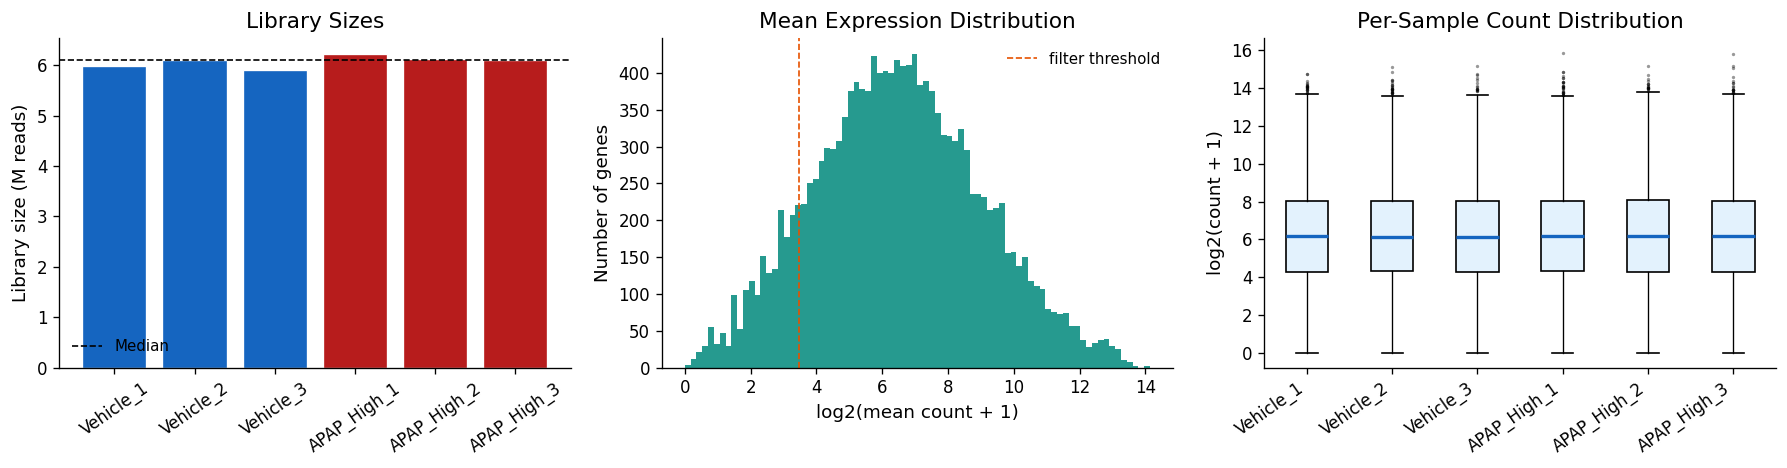

In [35]:
colors = ["#1565c0"] * N_CTRL + ["#b71c1c"] * N_TREAT

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Library sizes
ax = axes[0]
bars = ax.bar(sample_names, lib_sizes / 1e6, color=colors, edgecolor="white", linewidth=0.8)
ax.axhline(median_lib / 1e6, color="k", linestyle="--", lw=1, label="Median")
ax.set_ylabel("Library size (M reads)")
ax.set_title("Library Sizes")
ax.tick_params(axis="x", rotation=35)
ax.legend(frameon=False, fontsize=9)

# log2(mean count+1) distribution — shows count range
ax = axes[1]
log_mean = np.log2(counts.mean(axis=1) + 1)
ax.hist(log_mean, bins=80, color="#00897b", edgecolor="none", alpha=0.85)
ax.set_xlabel("log2(mean count + 1)")
ax.set_ylabel("Number of genes")
ax.set_title("Mean Expression Distribution")
ax.axvline(np.log2(10 + 1), color="#e65100", linestyle="--", lw=1, label="filter threshold")
ax.legend(frameon=False, fontsize=9)

# Per-sample boxplot of log-counts (detect normalization issues)
ax = axes[2]
log_counts = np.log2(counts + 1)
ax.boxplot(
    [log_counts[col].values for col in sample_names],
    labels=sample_names,
    patch_artist=True,
    boxprops=dict(facecolor="#e3f2fd"),
    medianprops=dict(color="#1565c0", lw=2),
    flierprops=dict(marker=".", markersize=2, alpha=0.4),
    whiskerprops=dict(lw=0.8),
)
ax.set_xticklabels(sample_names, rotation=35, ha="right")
ax.set_ylabel("log2(count + 1)")
ax.set_title("Per-Sample Count Distribution")

plt.tight_layout()
plt.savefig("rnaseq_qc_panels.png", dpi=150, bbox_inches="tight")
plt.show()

# Note: medians should be roughly equal across samples — large offsets suggest 
# library-size confounding that normalization must correct.

### 3b. Low-count filtering

**Why filter?** Genes with near-zero counts across all samples are uninformative but still contribute to the multiple-testing correction (inflating FDR). Removing them:
- Reduces the number of tests → lower adjusted p-values for true positives
- Removes numerical instability in dispersion estimation

**Standard criterion:** Keep genes with ≥ 10 total counts **in at least `min_replicates` samples**, where `min_replicates` = size of the smallest group. This is the default in DESeq2's `filterByExpr`.

In [36]:
MIN_COUNT      = 10
MIN_REPLICATES = min(N_CTRL, N_TREAT)

# Keep genes with ≥ MIN_COUNT reads in at least MIN_REPLICATES samples
keep_mask = (counts >= MIN_COUNT).sum(axis=1) >= MIN_REPLICATES
counts_f  = counts.loc[keep_mask]

n_removed = (~keep_mask).sum()
pct_kept  = keep_mask.sum() / len(counts) * 100

print(f"Genes before filtering   : {len(counts):>6,}")
print(f"Genes removed (low count): {n_removed:>6,}")
print(f"Genes retained           : {len(counts_f):>6,}  ({pct_kept:.1f}%)")

Genes before filtering   : 15,000
Genes removed (low count):  1,780
Genes retained           : 13,220  (88.1%)


---
## 4. PCA on variance-stabilized counts

PCA on raw or log counts reveals:
- Whether **biological groups separate** (treatment effect present)
- **Outlier samples** that should be removed
- **Batch effects** (unexpected clustering by processing day, not treatment)

We use **variance-stabilizing transformation (VST)**: `log2(count / size_factor + 1)`. This compresses the dynamic range and stabilizes variance across the count range, making PCA more interpretable than raw log-counts.

In [37]:
# Compute size factors (median-of-ratios, DESeq2 method)
def median_of_ratios(counts_df):
    """DESeq2 median-of-ratios normalization.
    
    For each gene, compute its ratio to the geometric mean across samples.
    A sample's size factor = median of those ratios across all genes.
    Robust to a minority of DE genes because the median ignores extremes.
    """
    log_counts = np.log(counts_df.replace(0, np.nan))
    log_geo_mean = log_counts.mean(axis=1)  # geometric mean via log mean
    # Keep genes with finite geometric mean (expressed in at least one sample)
    valid = log_geo_mean.notna() & np.isfinite(log_geo_mean)
    ratios = log_counts.loc[valid].subtract(log_geo_mean[valid], axis=0)
    size_factors = np.exp(ratios.median(axis=0))
    return size_factors

size_factors = median_of_ratios(counts_f)
print("Size factors:")
for sample, sf in size_factors.items():
    print(f"  {sample}: {sf:.4f}")

# VST: normalize then log-transform
norm_counts = counts_f.divide(size_factors, axis=1)
vst         = np.log2(norm_counts + 1)   # shape: (genes × samples)

# PCA on top 500 most-variable genes (reduces noise from housekeeping genes)
gene_var = vst.var(axis=1)
top_var  = gene_var.nlargest(500).index
X        = vst.loc[top_var].T.values   # shape: (samples × 500 genes)

X_scaled = StandardScaler().fit_transform(X)
pca      = PCA(n_components=min(N_SAMPLES, 4))
pcs      = pca.fit_transform(X_scaled)

pct_var  = pca.explained_variance_ratio_ * 100
print(f"\nPC1: {pct_var[0]:.1f}%   PC2: {pct_var[1]:.1f}%   (top-500 variable genes)")

Size factors:
  Vehicle_1: 1.0392
  Vehicle_2: 1.0372
  Vehicle_3: 1.0383
  APAP_High_1: 1.0475
  APAP_High_2: 1.0490
  APAP_High_3: 1.0419

PC1: 22.3%   PC2: 20.8%   (top-500 variable genes)


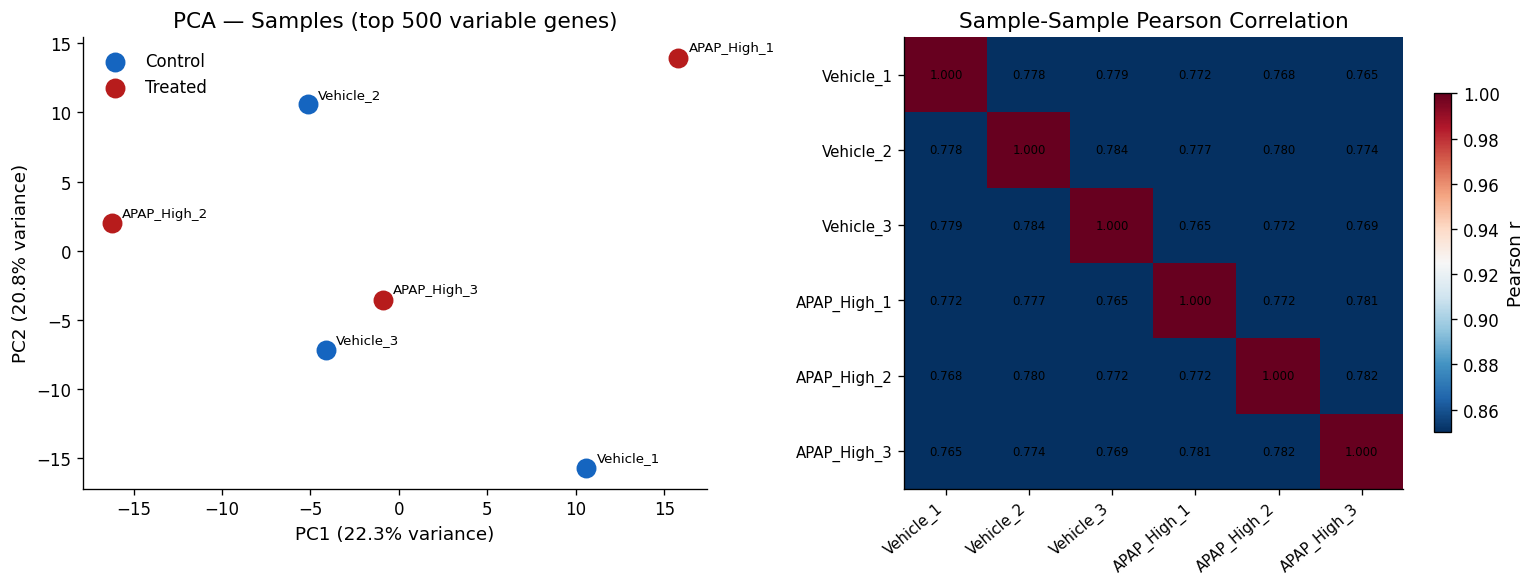

In [38]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- PCA scatter ---
ax = axes[0]
group_colors = ["#1565c0"] * N_CTRL + ["#b71c1c"] * N_TREAT
group_labels = ["Control"] * N_CTRL + ["Treated"] * N_TREAT

for i, (sample, color, label) in enumerate(zip(sample_names, group_colors, group_labels)):
    ax.scatter(
        pcs[i, 0], pcs[i, 1],
        c=color, s=120, zorder=3,
        label=label if i in (0, N_CTRL) else ""
    )
    ax.annotate(sample, (pcs[i, 0], pcs[i, 1]),
                textcoords="offset points", xytext=(6, 4), fontsize=8)

ax.set_xlabel(f"PC1 ({pct_var[0]:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pct_var[1]:.1f}% variance)")
ax.set_title("PCA — Samples (top 500 variable genes)")
handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(by_label.values(), by_label.keys(), frameon=False)

# --- Sample-sample correlation heatmap ---
ax = axes[1]
corr_mat = vst.corr(method="pearson")
# Reorder by group
order = ctrl_names + treat_names
corr_mat = corr_mat.loc[order, order]

im = ax.imshow(corr_mat.values, cmap="RdBu_r", vmin=0.85, vmax=1.0, aspect="auto")
ax.set_xticks(range(N_SAMPLES))
ax.set_yticks(range(N_SAMPLES))
ax.set_xticklabels(order, rotation=40, ha="right", fontsize=9)
ax.set_yticklabels(order, fontsize=9)
ax.set_title("Sample-Sample Pearson Correlation")
plt.colorbar(im, ax=ax, shrink=0.75, label="Pearson r")

# Annotate cells
for r in range(N_SAMPLES):
    for c in range(N_SAMPLES):
        ax.text(c, r, f"{corr_mat.iloc[r,c]:.3f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.savefig("rnaseq_pca_corr.png", dpi=150, bbox_inches="tight")
plt.show()

# INTERPRETATION:
# Good experiment: PC1 separates the two groups; replicates cluster together.
# Red blocks on the heatmap diagonal = within-group correlations should be high (r > 0.95).

---
## 5. Differential expression with DESeq2

### DESeq2 algorithm overview

1. **Size factor estimation** (median-of-ratios) — corrects for sequencing depth differences
2. **Dispersion estimation** — fits a gene-wise NB dispersion, then shrinks toward a mean-dispersion trend (empirical Bayes); prevents overfitting with few replicates
3. **GLM fitting** — fits a negative binomial GLM with the design matrix (`~ condition`)
4. **Wald test** — tests `H₀: LFC = 0` for each gene using Wald statistic `β/SE(β)`
5. **LFC shrinkage** (apeglm/ashr) — shrinks noisy LFC estimates for low-count genes; critical for ranking
6. **BH-FDR correction** — controls false discovery rate across all tested genes

In [39]:
# metadata (condition assignments) was built during data acquisition (Section 2).
# pydeseq2 requires samples as rows, genes as columns.
counts_for_deseq = counts_f.T   # shape: (samples × genes)

print("Metadata (condition assignments):")
print(metadata[["condition"]])
print(f"\nCounts passed to DESeq2: {counts_for_deseq.shape}")

Metadata (condition assignments):
            condition
Vehicle_1     control
Vehicle_2     control
Vehicle_3     control
APAP_High_1   treated
APAP_High_2   treated
APAP_High_3   treated

Counts passed to DESeq2: (6, 13220)


In [40]:
if PYDESEQ2_AVAILABLE:
    # --------------- Full DESeq2 pipeline ---------------
    dds = DeseqDataSet(
        counts=counts_for_deseq,
        metadata=metadata,
        design_factors="condition",   # single-factor design
        refit_cooks=True,             # refit outlier genes (Cook's distance)
        quiet=True,
    )
    dds.deseq2()   # runs steps 1–4: size factors, dispersion, GLM, Wald test

    stat_res = DeseqStats(
        dds,
        contrast=("condition", "treated", "control"),   # treated vs control
        alpha=0.05,
        cooks_filter=True,   # remove Cook's outliers from results
        quiet=True,
    )
    stat_res.summary()
    results = stat_res.results_df

else:
    # --------------- Fallback: NB-aware approach ---------------
    # Use Mann-Whitney U (non-parametric, no distributional assumption)
    # on normalized counts with BH correction — reasonable for exploratory use
    from statsmodels.stats.multitest import multipletests

    ctrl_cols  = ctrl_names
    treat_cols = treat_names

    def fallback_de(counts_df, ctrl_cols, treat_cols):
        rows = []
        norm = counts_df.divide(median_of_ratios(counts_df), axis=1)
        for gene in counts_df.index:
            c = norm.loc[gene, ctrl_cols].values.astype(float) + 0.5
            t = norm.loc[gene, treat_cols].values.astype(float) + 0.5
            lfc  = np.log2(t.mean()) - np.log2(c.mean())
            _, p = stats.mannwhitneyu(t, c, alternative="two-sided")
            rows.append({
                "gene": gene,
                "baseMean": (c.mean() + t.mean()) / 2,
                "log2FoldChange": lfc,
                "pvalue": p,
            })
        df = pd.DataFrame(rows).set_index("gene")
        _, padj, _, _ = multipletests(df["pvalue"].fillna(1), method="fdr_bh")
        df["padj"] = padj
        df["stat"] = np.nan
        df["lfcSE"] = np.nan
        return df.dropna(subset=["padj"]).sort_values("padj")

    results = fallback_de(counts_f, ctrl_cols, treat_cols)
    print("Fallback DE analysis complete (Mann-Whitney + BH correction)")

In [41]:
# Standard significance thresholds used in publications
PADJ_THRESH = 0.05
LFC_THRESH  = 1.0    # |log2FC| > 1 means at least 2-fold change

sig_mask = (results["padj"] < PADJ_THRESH) & (results["log2FoldChange"].abs() > LFC_THRESH)
sig      = results[sig_mask]
n_up     = (sig["log2FoldChange"] > 0).sum()
n_down   = (sig["log2FoldChange"] < 0).sum()

print(f"DEGs (padj < {PADJ_THRESH}, |LFC| > {LFC_THRESH}): {len(sig)}")
print(f"  Upregulated  : {n_up}")
print(f"  Downregulated: {n_down}")

print("\nTop 10 DEGs:")
display_cols = [c for c in ["baseMean", "log2FoldChange", "lfcSE", "stat", "pvalue", "padj"]
                if c in results.columns]
print(sig.head(10)[display_cols].round(4).to_string())

DEGs (padj < 0.05, |LFC| > 1.0): 186
  Upregulated  : 111
  Downregulated: 75

Top 10 DEGs:
                     baseMean  log2FoldChange   lfcSE    stat  pvalue    padj
ENSRNOG00000000000   447.2993          4.2933  1.0848  3.9576  0.0001  0.0103
ENSRNOG00000000001    32.4494          3.5391  1.0135  3.4919  0.0005  0.0401
ENSRNOG00000000002  1610.7175          2.0702  0.5019  4.1248  0.0000  0.0062
ENSRNOG00000000007   296.9856          3.4392  0.5965  5.7653  0.0000  0.0000
ENSRNOG00000000008   359.2309          2.7573  0.5506  5.0079  0.0000  0.0002
ENSRNOG00000000009    49.6621          2.1140  0.6107  3.4619  0.0005  0.0431
ENSRNOG00000000012   278.1007          4.6106  1.2363  3.7294  0.0002  0.0208
ENSRNOG00000000013  2258.8068          2.6361  0.4989  5.2838  0.0000  0.0001
ENSRNOG00000000014  1483.8935          3.3306  0.6703  4.9688  0.0000  0.0003
ENSRNOG00000000016   877.4930          3.5966  0.7304  4.9240  0.0000  0.0003


---
## 6. Visualization

### 6a. Volcano plot

The volcano plot is the standard summary of a DE experiment:
- **X-axis**: log2 fold change (effect size)
- **Y-axis**: −log10(adjusted p-value) (statistical significance)
- Dashed lines show the thresholds; labeled points are the top hits

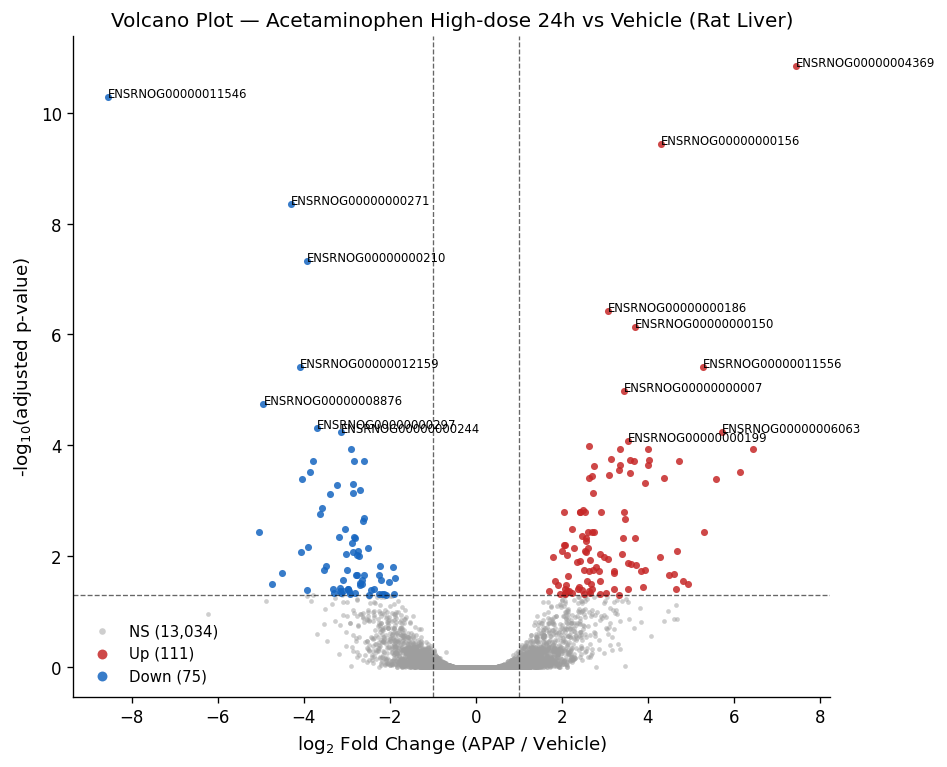

In [42]:
try:
    from adjustText import adjust_text
    HAS_ADJUSTTEXT = True
except ImportError:
    HAS_ADJUSTTEXT = False

def volcano_plot(results, padj_thresh=0.05, lfc_thresh=1.0, n_label=15, title=None, ax=None):
    """Publication-quality volcano plot."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 6.5))

    df = results.copy()
    df["neg_log10_padj"] = -np.log10(df["padj"].clip(lower=1e-300))

    up   = (df["log2FoldChange"] >  lfc_thresh) & (df["padj"] < padj_thresh)
    down = (df["log2FoldChange"] < -lfc_thresh) & (df["padj"] < padj_thresh)
    ns   = ~up & ~down

    scatter_kw = dict(linewidths=0, rasterized=True)
    ax.scatter(df.loc[ns,  "log2FoldChange"], df.loc[ns,  "neg_log10_padj"],
               c="#9e9e9e", s=8, alpha=0.5, label=f"NS ({ns.sum():,})", **scatter_kw)
    ax.scatter(df.loc[up,  "log2FoldChange"], df.loc[up,  "neg_log10_padj"],
               c="#c62828", s=18, alpha=0.85, label=f"Up ({up.sum():,})", **scatter_kw)
    ax.scatter(df.loc[down,"log2FoldChange"], df.loc[down,"neg_log10_padj"],
               c="#1565c0", s=18, alpha=0.85, label=f"Down ({down.sum():,})", **scatter_kw)

    ax.axhline(-np.log10(padj_thresh), color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axvline( lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axvline(-lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)

    top_genes = df.loc[up | down].nsmallest(n_label, "padj")
    texts = [
        ax.text(row["log2FoldChange"], row["neg_log10_padj"], gene, fontsize=7)
        for gene, row in top_genes.iterrows()
    ]
    if HAS_ADJUSTTEXT:
        adjust_text(texts, ax=ax, arrowprops=dict(arrowstyle="-", color="gray", lw=0.5))

    ax.set_xlabel("log$_2$ Fold Change (APAP / Vehicle)", fontsize=11)
    ax.set_ylabel("-log$_{10}$(adjusted p-value)", fontsize=11)
    ax.set_title(title or f"Volcano Plot — {COMPOUND} {DOSE}-dose {TIME_H}h vs Vehicle (Rat Liver)",
                 fontsize=12)
    ax.legend(frameon=False, markerscale=1.4, fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(8, 6.5))
volcano_plot(results, ax=ax)
plt.tight_layout()
plt.savefig("volcano.png", dpi=150, bbox_inches="tight")
plt.show()

### 6b. MA plot

The MA plot (Mean vs log-ratio) is **complementary to the volcano plot**:
- **X-axis**: average expression (log scale) — reveals expression-level bias
- **Y-axis**: log2 fold change

In a well-normalized experiment, non-DE genes (grey) should be symmetrically scattered around LFC = 0 across all expression levels. A systematic offset indicates poor normalization.

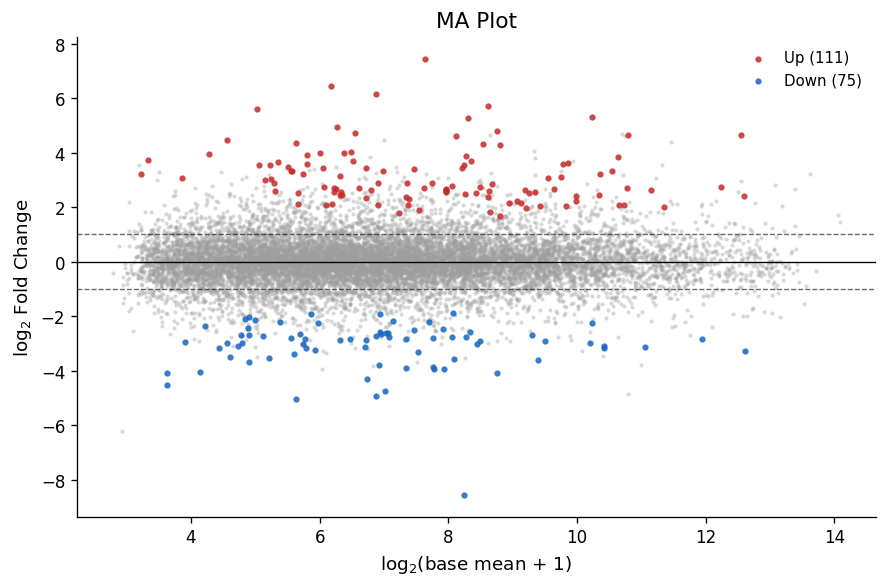

In [43]:
def ma_plot(results, padj_thresh=0.05, lfc_thresh=1.0, ax=None):
    """MA plot: log2(baseMean) vs log2FoldChange."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(7.5, 5))

    df = results.dropna(subset=["baseMean", "log2FoldChange", "padj"]).copy()
    df = df[df["baseMean"] > 0]
    df["log2_baseMean"] = np.log2(df["baseMean"] + 1)

    up   = (df["log2FoldChange"] >  lfc_thresh) & (df["padj"] < padj_thresh)
    down = (df["log2FoldChange"] < -lfc_thresh) & (df["padj"] < padj_thresh)
    ns   = ~up & ~down

    scatter_kw = dict(linewidths=0, rasterized=True)
    ax.scatter(df.loc[ns,  "log2_baseMean"], df.loc[ns,  "log2FoldChange"],
               c="#9e9e9e", s=6, alpha=0.4, **scatter_kw)
    ax.scatter(df.loc[up,  "log2_baseMean"], df.loc[up,  "log2FoldChange"],
               c="#c62828", s=14, alpha=0.85, label=f"Up ({up.sum()})", **scatter_kw)
    ax.scatter(df.loc[down,"log2_baseMean"], df.loc[down,"log2FoldChange"],
               c="#1565c0", s=14, alpha=0.85, label=f"Down ({down.sum()})", **scatter_kw)

    ax.axhline(0, color="black", lw=0.8)
    ax.axhline( lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)
    ax.axhline(-lfc_thresh, color="black", linestyle="--", lw=0.8, alpha=0.6)

    ax.set_xlabel("log$_2$(base mean + 1)", fontsize=11)
    ax.set_ylabel("log$_2$ Fold Change", fontsize=11)
    ax.set_title("MA Plot", fontsize=13)
    ax.legend(frameon=False, fontsize=9)
    return ax

fig, ax = plt.subplots(figsize=(7.5, 5))
ma_plot(results, ax=ax)
plt.tight_layout()
plt.savefig("ma_plot.png", dpi=150, bbox_inches="tight")
plt.show()

### 6c. Heatmap of top DEGs

A clustered heatmap shows **expression patterns** across samples for the top DEGs:
- Row clustering groups co-expressed genes (same regulatory program)
- Column clustering reveals sample relationships (should separate by condition)
- Values are **Z-scored** across samples to show relative change; otherwise high-expression genes dominate the color scale

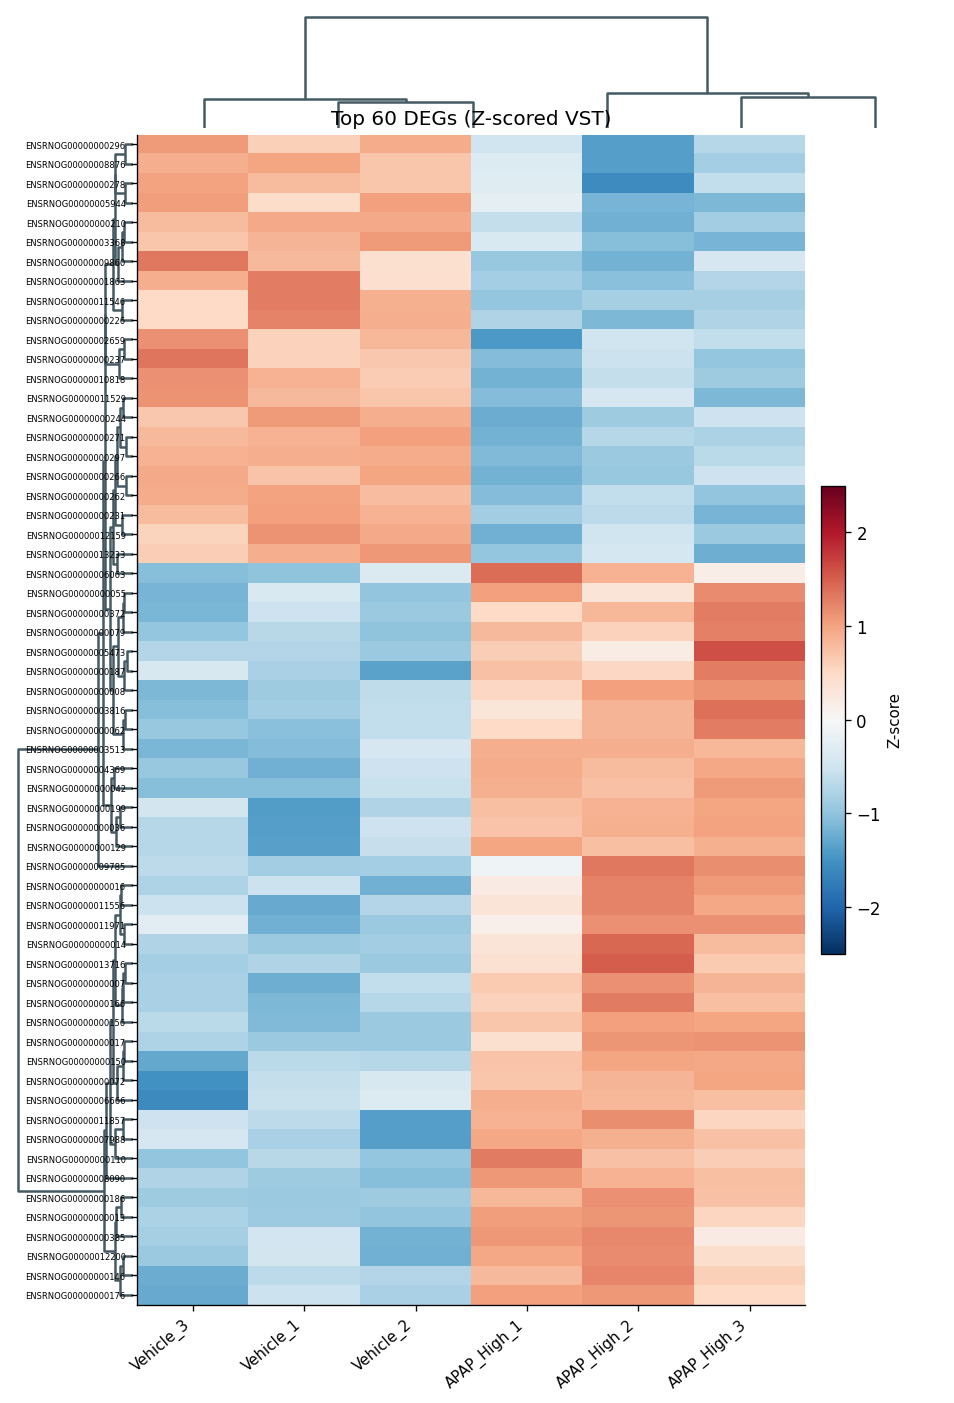

In [44]:
N_TOP = 60   # top N DEGs by adjusted p-value

top_degs = sig.nsmallest(N_TOP, "padj").index.tolist()

# Use VST-normalized values for display
heatmap_data = vst.loc[top_degs]   # shape: (N_TOP genes × samples)

# Z-score across samples (each gene: mean=0, sd=1)
zscored = heatmap_data.subtract(heatmap_data.mean(axis=1), axis=0)
zscored = zscored.divide(heatmap_data.std(axis=1) + 1e-9, axis=0)

# Hierarchical clustering
row_linkage = linkage(zscored.values, method="average", metric="euclidean")
col_linkage = linkage(zscored.T.values, method="average", metric="euclidean")

fig = plt.figure(figsize=(10, 14))
gs  = fig.add_gridspec(2, 2, width_ratios=[0.15, 1], height_ratios=[0.1, 1],
                        hspace=0.01, wspace=0.01)

# Column dendrogram
ax_col = fig.add_subplot(gs[0, 1])
dendrogram(col_linkage, ax=ax_col, orientation="top",
           link_color_func=lambda k: "#455a64")
ax_col.set_axis_off()
col_order = dendrogram(col_linkage, no_plot=True)["leaves"]

# Row dendrogram
ax_row = fig.add_subplot(gs[1, 0])
dendrogram(row_linkage, ax=ax_row, orientation="left",
           link_color_func=lambda k: "#455a64")
ax_row.set_axis_off()
row_order = dendrogram(row_linkage, no_plot=True)["leaves"]

# Heatmap
ax_heat = fig.add_subplot(gs[1, 1])
ordered  = zscored.iloc[row_order, col_order]
im = ax_heat.imshow(ordered.values, aspect="auto", cmap="RdBu_r",
                     vmin=-2.5, vmax=2.5, interpolation="nearest")

ax_heat.set_xticks(range(N_SAMPLES))
ax_heat.set_xticklabels([ordered.columns[i] for i in range(N_SAMPLES)],
                          rotation=40, ha="right", fontsize=9)
ax_heat.set_yticks(range(N_TOP))
ax_heat.set_yticklabels(ordered.index.tolist(), fontsize=5)
ax_heat.set_title(f"Top {N_TOP} DEGs (Z-scored VST)", fontsize=12, pad=6)

cb = plt.colorbar(im, ax=ax_heat, shrink=0.4, pad=0.02)
cb.set_label("Z-score", fontsize=9)

plt.savefig("heatmap_top_degs.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 7. Export results

Save outputs in formats compatible with downstream tools (Enrichr, GSEA, IPA).

In [45]:
# Full results table (all tested genes)
results.to_csv("deseq2_all_results.csv")

# Significant DEGs only
sig.to_csv("deseq2_sig_degs.csv")

# Gene list for Enrichr (just gene symbols, one per line)
sig.index.to_series().to_csv("deg_gene_list.txt", index=False, header=False)

# GSEA pre-ranked format: gene | ranking metric (sign(LFC) * -log10(padj))
rnk = results.copy()
rnk["rank_metric"] = (np.sign(rnk["log2FoldChange"]) *
                      -np.log10(rnk["pvalue"].clip(lower=1e-300)))
rnk[["rank_metric"]].dropna().sort_values("rank_metric", ascending=False).to_csv(
    "gsea_preranked.rnk", sep="\t", header=False
)

print("Saved:")
print("  deseq2_all_results.csv — full results (all genes)")
print("  deseq2_sig_degs.csv    — significant DEGs")
print("  deg_gene_list.txt      — gene list for Enrichr")
print("  gsea_preranked.rnk     — pre-ranked list for GSEA")

Saved:
  deseq2_all_results.csv — full results (all genes)
  deseq2_sig_degs.csv    — significant DEGs
  deg_gene_list.txt      — gene list for Enrichr
  gsea_preranked.rnk     — pre-ranked list for GSEA


---
## 8. Key takeaways

**Dataset:** Open TG-GATEs in vivo rat liver — acetaminophen (APAP) high-dose 24 h vs vehicle control  
**Portal:** https://toxico.nibiohn.go.jp/open-tggates/

| Decision point | Recommendation | Rationale |
|---|---|---|
| **Dataset source** | Open TG-GATEs (NIBIOHN) | 157 compounds × doses × time points; vehicle-matched controls; reproducible design |
| **Count model** | Negative binomial (DESeq2/edgeR) | RNA-Seq counts are overdispersed; NB > Poisson > t-test |
| **Normalization** | Median-of-ratios | Robust to DE genes; corrects composition bias |
| **Filter threshold** | ≥10 counts in ≥ n_min_group samples | Removes noise; improves multiple-testing power |
| **LFC threshold** | \|log2FC\| > 1 (2-fold) | Balances biological and statistical significance |
| **FDR threshold** | padj < 0.05 (BH) | Standard; controls expected false discovery proportion |
| **Visualization** | Volcano + MA + heatmap | Volcano: overview; MA: normalization check; heatmap: co-expression patterns |
| **Gene ranking for GSEA** | sign(LFC) × −log10(p) | Uses both effect size and significance; avoids arbitrary cutoffs |

### Expected APAP signature (rat liver, high dose, 24 h)
| Direction | Genes | Pathway |
|---|---|---|
| ↓ Down | *Cyp2e1*, *Cyp3a4*, *Cyp1a2* | CYP-mediated drug metabolism (NAPQI precursors suppressed) |
| ↑ Up | *Hmox1*, *Nqo1*, *Gclc*, *Txnrd1* | NRF2 oxidative-stress response |
| ↑ Up | *Tnf*, *Il6*, *Cxcl1*, *Lcn2* | Innate immune / inflammatory response to necrosis |
| ↑ Up | *Pcna*, *Mki67* | Hepatocyte regeneration (peaks at 24–48 h) |

### Common mistakes to avoid
- **Never use raw p-values** for genome-wide testing — always correct for multiple comparisons
- **Never log-transform then t-test** on count data with zeroes — pseudocount choice biases results
- **Always check PCA before DE** — a batch effect or sample swap will corrupt all results
- **LFC without shrinkage is noisy** — large/small LFCs for low-count genes are artefactual
